<a href="https://colab.research.google.com/github/danielsovres/Aulas/blob/main/ML_M%C3%A9todos_de_Boosting_AdaBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
Comentário pós aula

Os métodos de boosting treinam N modelos mais fracos, mas que tem uma performance
melhor quando são executados em conjunto.

Como exemplo, é demonstrado como funciona o AdaBoost
"""

# Aula 06 - Métodos de Boosting I - AdaBoost

Imaginemos a seguinte situação: precisamos modelar as vendas de um determinado produto para fazer previsões, o mais precisas quanto possível, das vendas por mês. Como poderíamos abordar este problema?

Em um primeiro momento, poderíamos, por exemplo, pensar em utilizar a média de vendas em um determinado período (como nos últimos 12 meses) como o valor a ser predito todos os meses. No entanto, é evidente que a performance desta abordagem deixaria muito a desejar, já que estaríamos simplesmente "chutando" a média de vendas o tempo todo. Contudo, pode nos servir como ponto de partida, e levantar o seguinte questionamento: *e se utilizássemos os erros do modelo como novas informações para o treinamento de um outro modelo?**

Este é o princípio do chamado **boosting:** utilizamos os erros no aprendizado de um modelo para treinar modelos subsequentes. Deste modo, a ideia é que "os modelos passem a aprender com os erros passados" e possam, assim, conjuntamente, performar melhor. Ou seja: *mesmo que a performance de cada um dos estimadores, individualmente, não seja boa, em conjunto, com o boosting, eles deveriam prover uma performance mais satisfatória!*

# "Trabalho em conjunto": Bagging x Boosting

Com o que discutimos até o momento, fica evidente que o método de **boosting** funciona a partir de um *conjunto* de modelos. O boosting não é a única abordagem neste viés de modelagem.

De fato, existem algumas maneiras de se criarem *comitês* de estimadores. A um grupo de modelos atuando conjuntamente, seja para fins de classificação ou regressão, chamamos comumente de **ensemble** (conjunto). A ideia de utilizar diversos estimadores conjuntamente tem por **objetivo combinar modelos mais simples em um único modelo mais robusto, a fim de reduzir o viés, a variância e/ou aumentar a acurácia**.

In [ ]:
#Ensemble = modelos mais simples em conjunto formam um modelo mais robusto

<div class="warning" style='padding:0.1em; background-color:#E9D8FD; color:#69337A'>
<span>
<h2>Algumas conceitualizações...</h2>
<ul>
<li>Podemos dizer que um modelo é um <b>weak learner</b> quando sua performance não é muito além de um "chute aleatório". <br><br>
    <li>Por outro lado, um <b>strong learner</b> possui alta performance e boa capacidade de generalização;<br><br>
<li>A ideia de métodos de ensemble é <b>combinar vários classificadores weak learners para gerar boas performances a custos computacionais mais baixos.
</ul>
</span>
<br>
</div>

## Alguns tipos de Ensemble:
- __1. Bagging (bootstrap aggregation)__: Treina paralelamente $N$ modelos mais fracos (geralmente do mesmo tipo) com $N$ subsets distintos criados com amostragem randômica e reposição. Cada modelo é avaliado na fase de teste com o label definido pela moda (classificação) ou pela média dos valores (regressão). Os métodos de Bagging reduzem a variância da predição. <br>
Algoritimos  famosos: Random Forest <br>
<img src='https://miro.medium.com/v2/resize:fit:828/format:webp/1*_pfQ7Xf-BAwfQXtaBbNTEg.png' style="width:600px"  text="https://miro.medium.com/v2/resize:fit:828/format:webp/1*_pfQ7Xf-BAwfQXtaBbNTEg.png" />  
<br>
<br>
- __2. Boosting__: Treina $N$ modelos mais fracos (geralmente do mesmo tipo) de **forma sequencial**. Os pontos que foram classificados erroneamente recebem um peso maior para entrar no próximo modelo. Na fase de teste, cada modelo é avaliado com base do erro de teste de cada modelo, e a predição é feita com um peso sobre a votação. Os métodos de Boosting reduzem o viés da predição. <br>
Algoritimos  famosos: AdaBoost, Gradient Boosting, XGBoost, CatBoost, LightGBM (Light Gradient Boosting Machine) <br>
<img src='https://media.geeksforgeeks.org/wp-content/uploads/20210707140911/Boosting.png' style="width:600px" text="Fonte: https://media.geeksforgeeks.org/wp-content/uploads/20210707140911/Boosting.png" />
<br>
<br>

##### Algumas leituras complementares:
[What is the difference between Bagging and Boosting?](https://quantdare.com/what-is-the-difference-between-bagging-and-boosting/)

[Bagging vs Boosting in Machine Learning](https://www.geeksforgeeks.org/bagging-vs-boosting-in-machine-learning/)


In [ ]:
#Semelhança = os dois reduzem a variância e dão mais estabilidade ao modelo
#Diferença - Boosting tenta reduzir o viés, Bagging não reduz
            # Bagging resolve overfitting - Boosting pode aumentar


# Boosting : AdaBoost

O AdaBoost significa **Adaptive Boosting**, e tem como procedimento geral **o encadeamento de sucessivos weak learners**, que, neste caso, constituem **árvores de um único nó (stumps)**.

<img src="https://miro.medium.com/max/1744/1*nJ5VrsiS1yaOR77d4h8gyw.png" width=300>

O AdaBoost utiliza os **erros da árvore anterior para melhorar a próxima árvore**. As predições finais são feitas com base **nos pesos de cada stump**, cuja determinação faz parte do algoritmo!

<img src="https://static.packt-cdn.com/products/9781788295758/graphics/image_04_046-1.png" width=700>

Vamos entender um pouco melhor...

Aqui, o bootstrapping não é utilizado: o método começa treinando um classificador fraco **no dataset original**, e depois treina diversas cópias adicionais do classificador **no mesmo dataset**, mas dando **um peso maior às observações que foram classificadas erroneamente** (ou, no caso de regressões, a observações **com o maior erro**).

Assim, após diversas iterações, classificadores/regressores vão sequencialmente "focando nos casos mais difíceis", e construindo um classificador encadeado que seja forte, apesar de utilizar diversos classificadores fracos em como elementos fundamentais.

<img src="https://www.researchgate.net/profile/Zhuo_Wang8/publication/288699540/figure/fig9/AS:668373486686246@1536364065786/Illustration-of-AdaBoost-algorithm-for-creating-a-strong-classifier-based-on-multiple.png" width=500>

De forma resumida, as principais ideias por trás deste algoritmo são:

- O algoritmo cria e combina um conjunto de **modelos fracos** (em geral, stumps);
- Cada stump é criado **levando em consideração os erros do stump anterior**;
- Alguns dos stumps têm **maior peso de decisão** do que outros na predição final;

As classes no sklearn são:

- [AdaBoostClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html)

- [AdaBoostRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostRegressor.html#sklearn.ensemble.AdaBoostRegressor)

Note que não há muitos hiperparâmetros. O mais importante, que deve ser tunado com o grid/random search, é:

- `n_estimators` : o número de weak learners encadeados;

Além disso, pode também ser interessante tunar os hiperparâmetros dos weak learners. Isso é possível de ser feito, como veremos a seguir!


___
### AdaBoost: um caso prático

Como exemplo, vamos utilizar uma base de dados sobre [risco de crédito](https://www.kaggle.com/datasets/uciml/german-credit).

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("datasets/german_credit_data.csv", index_col=0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 85.9+ KB


In [ ]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Primeiramente, vamos processar nossos dados com as seguintes etapas:
- normalizar os dados oriundos de colunas numéricas
- utilizar o one hot encoding nas colunas categóricas.

Dividindo os dados de treino e teste:

In [ ]:
X = df.drop(columns="Risk") #features
y = df["Risk"] #target
features_num = X.select_dtypes(include=np.number).columns.tolist() #selecionar só variáveis numéricos e transformar na variável features_num
X = X[features_num] #substituo as colunas em X pelas em features_num

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) #dividir treino e teste


scaler = StandardScaler() #importar scaler
X_train[features_num] = scaler.fit_transform(X_train[features_num]) #fitar e transformar os dados de treino
X_test[features_num] = scaler.transform(X_test[features_num]) #transformar os dados de teste

In [ ]:
X_train #dados de treino

,Age,Job,Credit amount,Duration
328,-0.391895,0.130494,0.440600,1.217731
891,0.943243,0.130494,-0.501243,-0.492631
255,-0.747932,-1.417743,1.489665,3.172429
243,-0.747932,0.130494,-0.730649,-0.736968
492,-0.747932,0.130494,-0.712125,-1.225643
...,...,...,...,...
73,0.498197,-1.417743,0.968160,1.706405
401,-0.658922,0.130494,-0.480583,-0.248293
769,2.456400,-1.417743,-0.563226,-0.736968
2,1.210271,-1.417743,-0.406133,-0.736968


[AdaBoost classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html)

In [ ]:
from sklearn.ensemble import AdaBoostClassifier #importar o classificador

In [ ]:
adaboost = AdaBoostClassifier()
adaboost.fit(X_train, y_train)

AdaBoostClassifier()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

In [ ]:
y_pred_train = adaboost.predict(X_train) #cria y_pred_train
y_pred_test = adaboost.predict(X_test) #cria y_pred_test

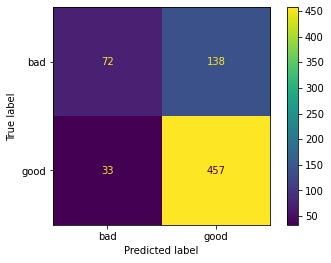

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train) #cria matriz de confusão de treino
# verdadeiro positivo (certo) - falso positivo (errado)
# falso negativo (errado) - verdadeiro negativo (certo)

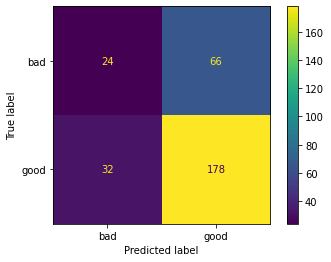

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test) #cria matriz de confusão de teste

Usando $n_{estimators} = 150$ (apenas um "chute")

Treinamento:


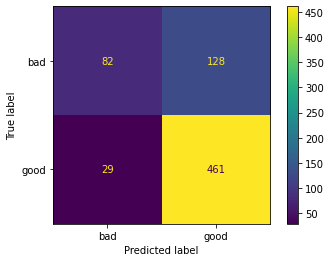

Teste:


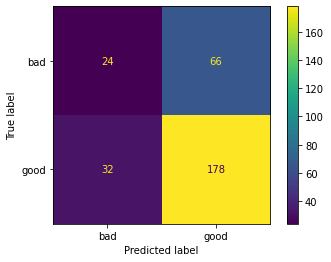

In [ ]:
adaboost = AdaBoostClassifier(n_estimators = 150, random_state = 42)
#padrão = 50 estimadores - aqui, o sistema define no mínimo 150 estimadores
#tentativa de prever melhor
adaboost.fit(X_train, y_train)

y_pred_train = adaboost.predict(X_train)
y_pred_test = adaboost.predict(X_test)

print("Treinamento:")
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train)
plt.show()


print("="*30)


print("Teste:")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
plt.show()

In [ ]:
print(classification_report(y_pred_train, y_train)) #report de treinamento

#Precision: De todos que o modelo disse que eram "Sim", quantos ele acertou de verdade?
#Recall: De todos os "Sim" que existiam no mundo real, quantos o modelo conseguiu encontrar?
#F1-Score: É o equilíbrio (uma nota única) entre a precisão e o recall.
#Support: É a quantidade real de exemplos que cada classe tinha no seu teste.

              precision    recall  f1-score   support

         bad       0.39      0.74      0.51       111
        good       0.94      0.78      0.85       589

    accuracy                           0.78       700
   macro avg       0.67      0.76      0.68       700
weighted avg       0.85      0.78      0.80       700



In [ ]:
print(classification_report(y_pred_test, y_test)) #report de teste

              precision    recall  f1-score   support

         bad       0.27      0.43      0.33        56
        good       0.85      0.73      0.78       244

    accuracy                           0.67       300
   macro avg       0.56      0.58      0.56       300
weighted avg       0.74      0.67      0.70       300



___
Nesta aula, aplicamos um classificador de ensemble do tipo **AdaBoost** para predição de risco de crédito. Obtivemos uma performance razoável, embora ainda esteja longe da ideal. Posteriormente, estudaremos ferramentas que nos auxiliarão a otimizar os parâmetros do modelo, para que possamos obter resultados melhores!